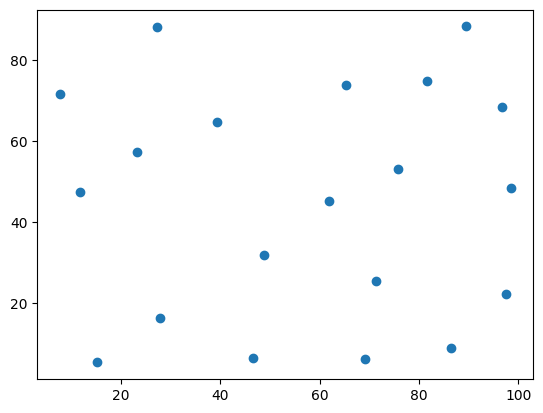

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random, time

# --- Step 1: Generate 20 random points with min distance > 10 ---
num_points = 20
min_dist = 15
num_routes = 3

def generate_points(n, min_dist):
    points = []
    while len(points) < n:
        candidate = np.random.rand(2) * 100  # random in [0,100]x[0,100]
        if all(np.linalg.norm(candidate - p) > min_dist for p in points):
            points.append(candidate)
    return np.array(points)

points = generate_points(num_points, min_dist)
plt.scatter(points[:,0],points[:,1])

In [12]:
# --- Distance function ---
def distance(a, b):
    return np.linalg.norm(points[a] - points[b])

def route_cost(route):
    if len(route) <= 1:
        return 0
    return sum(distance(route[i], route[(i+1)%len(route)]) for i in range(len(route)))

# --- Split chromosome into 3 routes ---
def split_routes(chromosome):
    """Split a list of points into 3 roughly equal parts"""
    parts = np.array_split(chromosome, num_routes)
    return [list(p) for p in parts]

# --- Compute total cost of chromosome ---
def total_cost(chromosome):
    routes = split_routes(chromosome)
    return sum(route_cost(r) for r in routes)

# --- Random route (permutation of 0..19) ---
def random_route():
    route = list(range(num_points))
    random.shuffle(route)
    return route


In [13]:
# === GA functions ===
def crossover(p1, p2):
    """Order crossover (OX style)"""
    a, b = sorted(random.sample(range(num_points), 2))
    child = [-1]*num_points
    child[a:b] = p1[a:b]
    fill = [gene for gene in p2 if gene not in child]
    idx = 0
    for i in range(num_points):
        if child[i] == -1:
            child[i] = fill[idx]
            idx += 1
    return child

def mutate(chrom):
    """Swap two points"""
    i, j = random.sample(range(num_points), 2)
    chrom[i], chrom[j] = chrom[j], chrom[i]
    return chrom


In [14]:
pop_size = 50
num_generations = 30
population = [random_route() for _ in range(pop_size)]
best_costs = []

# === GA loop ===
for gen in range(num_generations):
    population.sort(key=total_cost)
    best_cost = total_cost(population[0])
    best_costs.append(best_cost)
    print(f"Generation {gen+1}: Best cost = {best_cost:.2f}")

    new_pop = population[:10]  # elitism (keep best 10)

    # Crossover: 32 children
    for _ in range(32):
        p1, p2 = random.sample(population[:25], 2)
        new_pop.append(crossover(p1, p2))

    # Mutation: 14 children
    for _ in range(14):
        p = random.choice(population[:20])
        new_pop.append(mutate(p.copy()))

    # New random: 4
    for _ in range(4):
        new_pop.append(random_route())

    population = new_pop
# === Results ===
best = min(population, key=total_cost)
best_routes = split_routes(best)

print("\n=== Best Routes ===")
for i, r in enumerate(best_routes):
    print(f"Driver {i+1}: {r}, cost = {route_cost(r):.2f}")
print(f"Total cost = {total_cost(best):.2f}")

Generation 1: Best cost = 872.59
Generation 2: Best cost = 816.87
Generation 3: Best cost = 807.61
Generation 4: Best cost = 801.96
Generation 5: Best cost = 795.05
Generation 6: Best cost = 704.84
Generation 7: Best cost = 704.84
Generation 8: Best cost = 700.38
Generation 9: Best cost = 700.38
Generation 10: Best cost = 679.01
Generation 11: Best cost = 668.50
Generation 12: Best cost = 668.41
Generation 13: Best cost = 661.16
Generation 14: Best cost = 656.46
Generation 15: Best cost = 656.46
Generation 16: Best cost = 656.46
Generation 17: Best cost = 641.57
Generation 18: Best cost = 641.57
Generation 19: Best cost = 611.40
Generation 20: Best cost = 611.40
Generation 21: Best cost = 611.40
Generation 22: Best cost = 611.40
Generation 23: Best cost = 609.54
Generation 24: Best cost = 598.10
Generation 25: Best cost = 598.10
Generation 26: Best cost = 598.10
Generation 27: Best cost = 583.52
Generation 28: Best cost = 583.52
Generation 29: Best cost = 583.52
Generation 30: Best cos

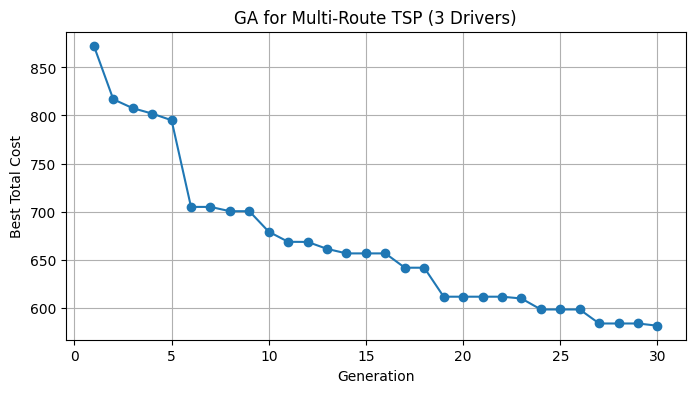

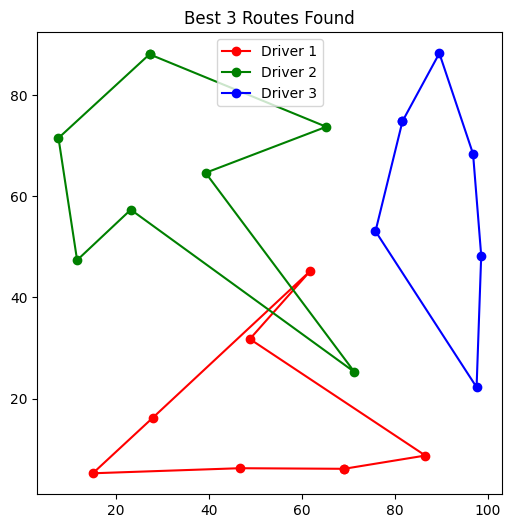

In [15]:
# === Plot best cost per generation ===
plt.figure(figsize=(8,4))
plt.plot(range(1, num_generations+1), best_costs, marker='o')
plt.title("GA for Multi-Route TSP (3 Drivers)")
plt.xlabel("Generation")
plt.ylabel("Best Total Cost")
plt.grid(True)
plt.show()

# === Visualize best routes ===
colors = ['r','g','b']
plt.figure(figsize=(6,6))
for i, route in enumerate(best_routes):
    route_points = np.array([points[j] for j in route + [route[0]]])
    plt.plot(route_points[:,0], route_points[:,1], '-o', color=colors[i], label=f"Driver {i+1}")
plt.title("Best 3 Routes Found")
plt.legend()
plt.show()